In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten to 784
])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root="./data", train=True, download=True, transform=transform),
    batch_size=256,
    shuffle=True
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 9.49MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 299kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.86MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.52MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [11]:
class Coupling(nn.Module):
    def __init__(self, dim, mask):
        super().__init__()
        self.mask = mask
        self.net = nn.Sequential(
            nn.Linear(dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, dim)
        )

    def forward(self, x):
        x_masked = x * self.mask
        shift = self.net(x_masked) * (1 - self.mask)
        return x + shift

    def inverse(self, y):
        y_masked = y * self.mask
        shift = self.net(y_masked) * (1 - self.mask)
        return y - shift


In [4]:
class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=6):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            mask = (torch.arange(dim) % 2).float()
            if i % 2 == 1:
                mask = 1 - mask
            self.layers.append(Coupling(dim, mask))

    def forward(self, z):
        for layer in self.layers:
            z = layer(z)
        return z

    def inverse(self, x):
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x


In [5]:
dim = 28 * 28
base = torch.distributions.Normal(0, 1)

def log_prob(flow, x):
    z = flow.inverse(x)
    return base.log_prob(z).sum(dim=1)


In [12]:
flow = RealNVP(dim, 12)
optimizer = optim.Adam(flow.parameters(), lr=1e-3)

for epoch in range(20):
    for x, _ in train_loader:
        optimizer.zero_grad()
        loss = -log_prob(flow, x).mean()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, NLL: {loss.item():.2f}")


Epoch 0, NLL: 726.63
Epoch 1, NLL: 724.33
Epoch 2, NLL: 723.69
Epoch 3, NLL: 723.02
Epoch 4, NLL: 723.11
Epoch 5, NLL: 722.76
Epoch 6, NLL: 722.52
Epoch 7, NLL: 722.19
Epoch 8, NLL: 722.12
Epoch 9, NLL: 722.09
Epoch 10, NLL: 721.78
Epoch 11, NLL: 721.75
Epoch 12, NLL: 721.71
Epoch 13, NLL: 721.89
Epoch 14, NLL: 723.79
Epoch 15, NLL: 722.49
Epoch 16, NLL: 722.04
Epoch 17, NLL: 721.91
Epoch 18, NLL: 721.64
Epoch 19, NLL: 721.77


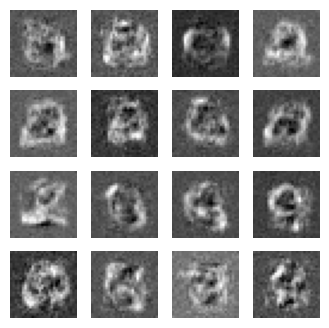

In [13]:
with torch.no_grad():
    z = torch.randn(16, dim)
    samples = flow.forward(z).view(-1, 28, 28)

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i], cmap="gray")
    plt.axis("off")
plt.show()

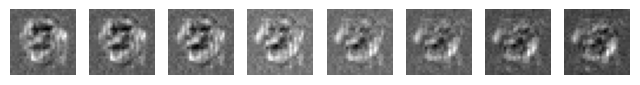

In [14]:
with torch.no_grad():
    z1 = torch.randn(1, dim)
    z2 = torch.randn(1, dim)
    alphas = torch.linspace(0, 1, 8)

    imgs = []
    for a in alphas:
        z = (1-a)*z1 + a*z2
        imgs.append(flow.forward(z).view(28,28))

plt.figure(figsize=(8,2))
for i,img in enumerate(imgs):
    plt.subplot(1,8,i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
plt.show()
